In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error,root_mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
df_raw =pd.read_csv(r"C:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\New_Data\Electricity Demand\continuous dataset.csv",parse_dates=['datetime'])

In [3]:
df_raw.dtypes

datetime      datetime64[ns]
nat_demand           float64
T2M_toc              float64
QV2M_toc             float64
TQL_toc              float64
W2M_toc              float64
T2M_san              float64
QV2M_san             float64
TQL_san              float64
W2M_san              float64
T2M_dav              float64
QV2M_dav             float64
TQL_dav              float64
W2M_dav              float64
Holiday_ID             int64
holiday                int64
school                 int64
dtype: object

In [4]:
df_raw

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48043,2020-06-26 20:00:00,1128.5592,27.246545,0.020303,0.055511,9.289304,25.715295,0.019746,0.121552,1.990773,23.746545,0.018381,0.150879,2.444658,0,0,1
48044,2020-06-26 21:00:00,1112.7488,27.099573,0.020395,0.053848,9.837504,25.552698,0.019632,0.153870,2.094459,23.693323,0.018320,0.156311,2.515814,0,0,1
48045,2020-06-26 22:00:00,1081.5680,26.971155,0.020448,0.057251,10.262464,25.393030,0.019518,0.144531,2.396369,23.658655,0.018327,0.153259,2.800717,0,0,1
48046,2020-06-26 23:00:00,1041.6240,26.867487,0.020464,0.064178,10.326567,25.258112,0.019403,0.108063,2.720871,23.601862,0.018358,0.152771,3.138132,0,0,1


In [5]:
rename_dict = {
    "nat_demand": "electricity_demand",

    "T2M_toc": "temp_tocumen",
    "QV2M_toc": "humidity_tocumen",
    "TQL_toc": "cloud_liquid_tocumen",
    "W2M_toc": "wind_speed_tocumen",

    "T2M_san": "temp_san_miguelito",
    "QV2M_san": "humidity_san_miguelito",
    "TQL_san": "cloud_liquid_san_miguelito",
    "W2M_san": "wind_speed_san_miguelito",

    "T2M_dav": "temp_david",
    "QV2M_dav": "humidity_david",
    "TQL_dav": "cloud_liquid_david",
    "W2M_dav": "wind_speed_david",

    "Holiday_ID": "holiday_type_id",
    "holiday": "is_holiday",
    "school": "is_school_day"
}

df = df_raw.rename(columns=rename_dict)

In [6]:
df

,datetime,electricity_demand,temp_tocumen,humidity_tocumen,cloud_liquid_tocumen,wind_speed_tocumen,temp_san_miguelito,humidity_san_miguelito,cloud_liquid_san_miguelito,wind_speed_san_miguelito,temp_david,humidity_david,cloud_liquid_david,wind_speed_david,holiday_type_id,is_holiday,is_school_day
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48043,2020-06-26 20:00:00,1128.5592,27.246545,0.020303,0.055511,9.289304,25.715295,0.019746,0.121552,1.990773,23.746545,0.018381,0.150879,2.444658,0,0,1
48044,2020-06-26 21:00:00,1112.7488,27.099573,0.020395,0.053848,9.837504,25.552698,0.019632,0.153870,2.094459,23.693323,0.018320,0.156311,2.515814,0,0,1
48045,2020-06-26 22:00:00,1081.5680,26.971155,0.020448,0.057251,10.262464,25.393030,0.019518,0.144531,2.396369,23.658655,0.018327,0.153259,2.800717,0,0,1
48046,2020-06-26 23:00:00,1041.6240,26.867487,0.020464,0.064178,10.326567,25.258112,0.019403,0.108063,2.720871,23.601862,0.018358,0.152771,3.138132,0,0,1


In [25]:
# numeric_cols = df.select_dtypes(include='number').columns
# for col in numeric_cols:
#     plt.figure(figsize=(10, 4))
#     sns.boxplot(df[col])
#     plt.title(f'Distribution of {col}')
#     plt.xlabel(col)
#     plt.ylabel('Frequency')
#     plt.show()

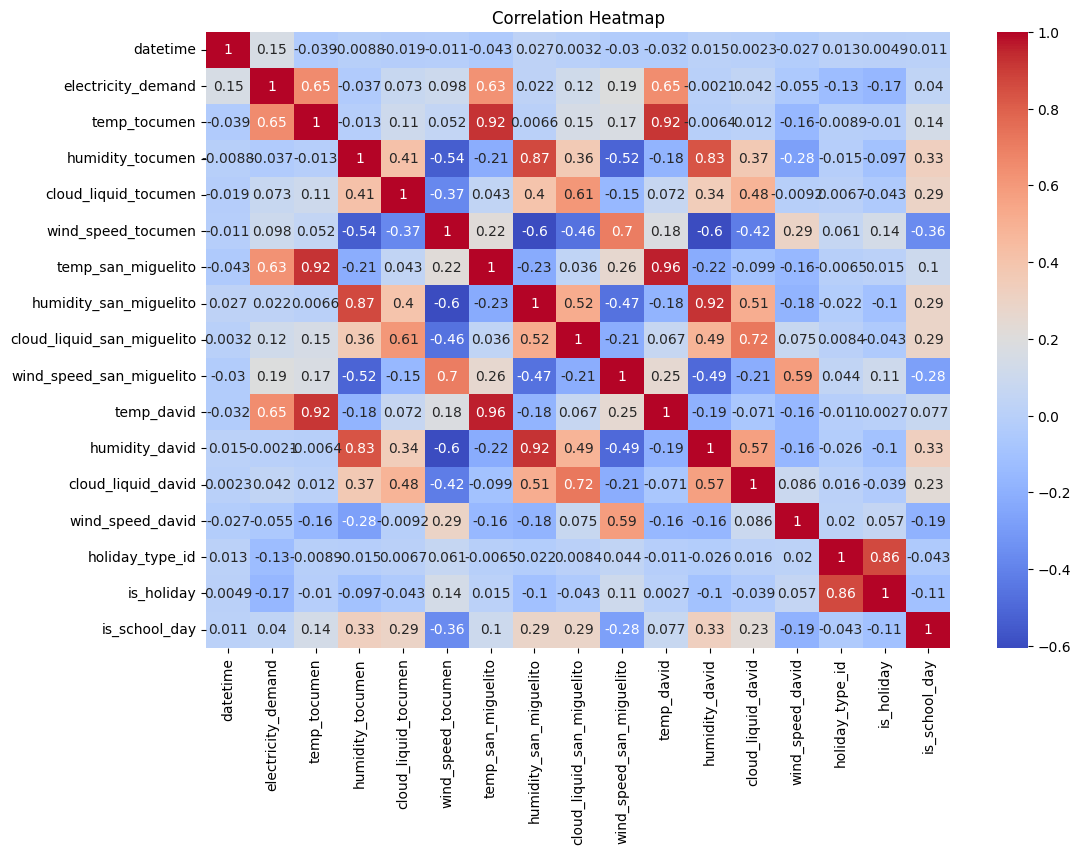

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [9]:
corr = df.corr(numeric_only=True)

# Correlation with target
corr_target = corr["electricity_demand"].sort_values(ascending=False)
print(corr_target)

electricity_demand            1.000000
temp_tocumen                  0.652811
temp_david                    0.648279
temp_san_miguelito            0.627024
wind_speed_san_miguelito      0.191796
cloud_liquid_san_miguelito    0.119038
wind_speed_tocumen            0.098435
cloud_liquid_tocumen          0.073109
cloud_liquid_david            0.042037
is_school_day                 0.040044
humidity_san_miguelito        0.022172
humidity_david               -0.002117
humidity_tocumen             -0.036706
wind_speed_david             -0.054802
holiday_type_id              -0.129834
is_holiday                   -0.165673
Name: electricity_demand, dtype: float64


In [30]:
data_tsa = pd.DataFrame(df.set_index('datetime')['electricity_demand'],columns=['electricity_demand'])

In [31]:
data_tsa

,electricity_demand
datetime,
2015-01-03 01:00:00,970.3450
2015-01-03 02:00:00,912.1755
2015-01-03 03:00:00,900.2688
2015-01-03 04:00:00,889.9538
2015-01-03 05:00:00,893.6865
...,...
2020-06-26 20:00:00,1128.5592
2020-06-26 21:00:00,1112.7488
2020-06-26 22:00:00,1081.5680


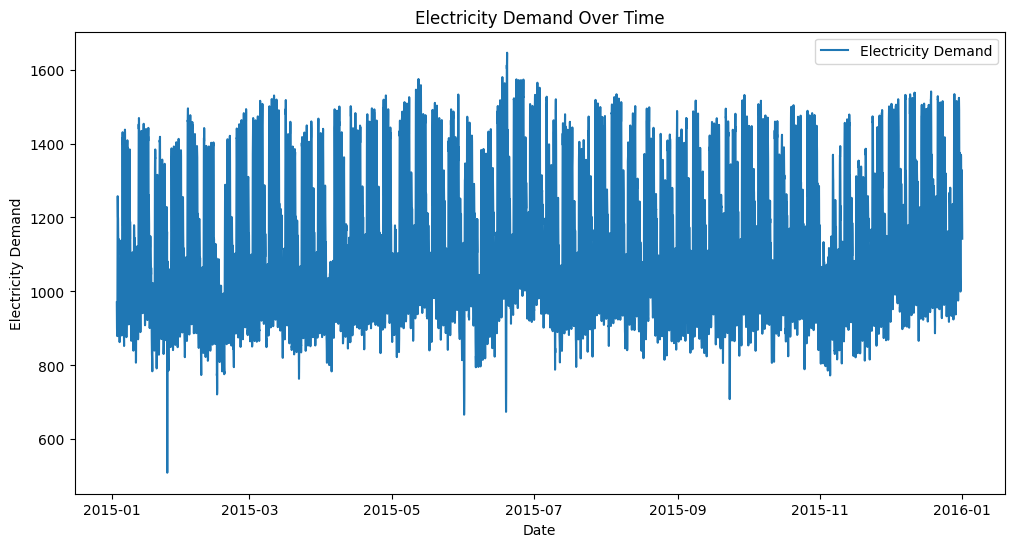

In [12]:
plt.figure(figsize=(12, 6))
data_2015 = data_tsa[data_tsa.index.year == 2015]
plt.plot('electricity_demand', data=data_2015, label='Electricity Demand')
plt.title('Electricity Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Electricity Demand')
plt.legend()
plt.show()

In [13]:
adf_test = adfuller(data_tsa['electricity_demand'])


In [14]:
adf_test

(np.float64(-20.961750007296583),
 0.0,
 57,
 47990,
 {'1%': np.float64(-3.430486271094305),
  '5%': np.float64(-2.861600228969454),
  '10%': np.float64(-2.5668020578981667)},
 np.float64(451857.2057186888))

In [44]:
data_tsa = pd.DataFrame(df.set_index('datetime')['electricity_demand'],columns=['electricity_demand'])
# data_tsa = data_tsa[data_tsa.index.year  == 2018]

In [ ]:
# data_tsa= data_tsa.resample('D').mean()

In [45]:
data_tsa

,electricity_demand
datetime,
2015-01-03 01:00:00,970.3450
2015-01-03 02:00:00,912.1755
2015-01-03 03:00:00,900.2688
2015-01-03 04:00:00,889.9538
2015-01-03 05:00:00,893.6865
...,...
2020-06-26 20:00:00,1128.5592
2020-06-26 21:00:00,1112.7488
2020-06-26 22:00:00,1081.5680


In [ ]:
# auto_arima_model = auto_arima(data_tsa['electricity_demand'], seasonal=True, m=24,stepwise=True, suppress_warnings=True,trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=83557.742, Time=38.02 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=116365.806, Time=0.06 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=inf, Time=17.43 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=100486.650, Time=6.77 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=149367.444, Time=0.03 sec
 ARIMA(2,0,2)(0,0,1)[24] intercept   : AIC=85481.409, Time=25.65 sec
 ARIMA(2,0,2)(1,0,0)[24] intercept   : AIC=83823.184, Time=129.68 sec
 ARIMA(2,0,2)(2,0,1)[24] intercept   : AIC=inf, Time=261.77 sec
 ARIMA(2,0,2)(1,0,2)[24] intercept   : AIC=83559.917, Time=306.54 sec
 ARIMA(2,0,2)(0,0,0)[24] intercept   : AIC=89227.932, Time=4.27 sec
 ARIMA(2,0,2)(0,0,2)[24] intercept   : AIC=83944.840, Time=123.65 sec
 ARIMA(2,0,2)(2,0,0)[24] intercept   : AIC=83521.730, Time=311.83 sec
 ARIMA(1,0,2)(2,0,0)[24] intercept   : AIC=80797.803, Time=115.49 sec
 ARIMA(1,0,2)(1,0,0)[24] intercept   : AIC=81864.770, Time=26.58 se

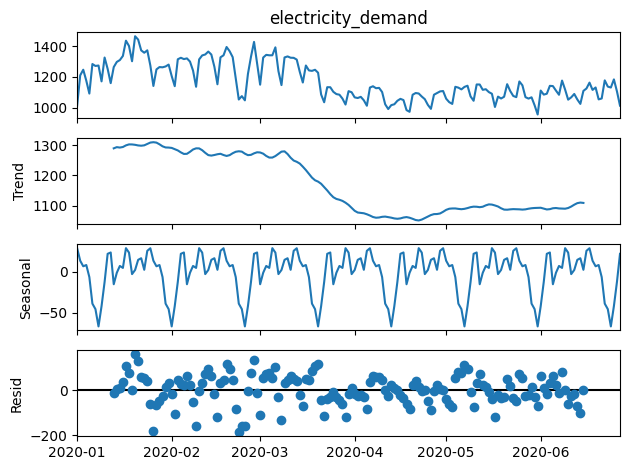

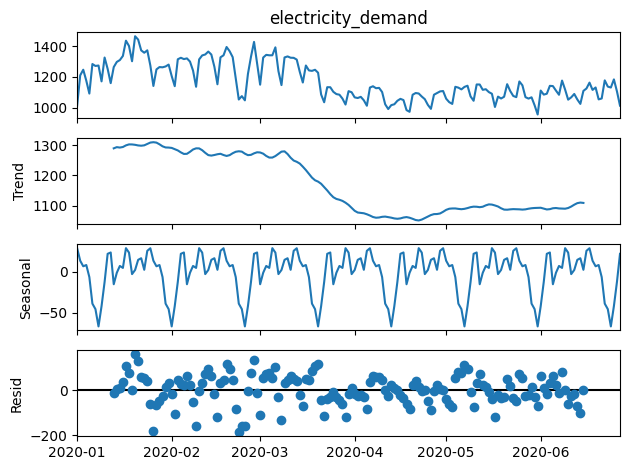

In [29]:
results = seasonal_decompose(data_tsa['electricity_demand'], model='additive', period=24)
results.plot()

In [27]:
auto_arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  179
Model:             SARIMAX(3, 1, 3)x(0, 0, [1], 24)   Log Likelihood                -964.686
Date:                              Sat, 28 Mar 2026   AIC                           1945.373
Time:                                      15:57:03   BIC                           1970.827
Sample:                                  01-01-2020   HQIC                          1955.695
                                       - 06-27-2020                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2725      0.115      2.362      0.018       0.046       0.499
ar.L2         -0.6730      0.055    -12.319      0.000      -0.780      -0.566
ar.L3          0.7218      0.117      6.188      0.000       0.493       0.950
ma.L1         -0.4483      0.114     -3.935      0.000      -0.672      -0.225
ma.L2          0.5351      0.063      8.462      0.000       0.411       0.659
ma.L3         -0.8632      0.087     -9.880      0.000      -1.034      -0.692
ma.S.L24      -0.2847      0.092     -3.104      0.002      -0.464      -0.105
sigma2      3237.1721    421.810      7.674      0.000    2410.440    4063.904
===================================================================================
Ljung-Box (L1) (Q):                   0.65   Jarque-Bera (JB):                 2.84
Prob(Q):                              0.42   Prob(JB):                         0.24
Heteroskedasticity (H):               0.30   Skew:                             0.31
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [28]:
# SARIMAX(3, 1, 3)x(0, 0, [1], 24)	

In [46]:
data_tsa.sort_index(inplace=True)

In [47]:
data_tsa

,electricity_demand
datetime,
2015-01-03 01:00:00,970.3450
2015-01-03 02:00:00,912.1755
2015-01-03 03:00:00,900.2688
2015-01-03 04:00:00,889.9538
2015-01-03 05:00:00,893.6865
...,...
2020-06-26 20:00:00,1128.5592
2020-06-26 21:00:00,1112.7488
2020-06-26 22:00:00,1081.5680


In [48]:
print(corr_target)

electricity_demand            1.000000
temp_tocumen                  0.652811
temp_david                    0.648279
temp_san_miguelito            0.627024
wind_speed_san_miguelito      0.191796
cloud_liquid_san_miguelito    0.119038
wind_speed_tocumen            0.098435
cloud_liquid_tocumen          0.073109
cloud_liquid_david            0.042037
is_school_day                 0.040044
humidity_san_miguelito        0.022172
humidity_david               -0.002117
humidity_tocumen             -0.036706
wind_speed_david             -0.054802
holiday_type_id              -0.129834
is_holiday                   -0.165673
Name: electricity_demand, dtype: float64


In [50]:
df['Average_Temp'] = df[['temp_tocumen', 'temp_san_miguelito', 'temp_david']].mean(axis=1)

In [52]:
df['Average_Wind_Speed'] = df[['wind_speed_tocumen', 'wind_speed_san_miguelito', 'wind_speed_david']].mean(axis=1)

In [53]:
df['Average_cloud_liquid'] = df[['cloud_liquid_tocumen', 'cloud_liquid_san_miguelito', 'cloud_liquid_david']].mean(axis=1)

In [58]:
df_new = df[['datetime', 'electricity_demand', 'Average_Temp', 'is_holiday', 'is_school_day','holiday_type_id','Average_Wind_Speed','Average_cloud_liquid']]

In [60]:
df_new =df_new.set_index('datetime')

In [61]:
df_new.dtypes

electricity_demand      float64
Average_Temp            float64
is_holiday                int64
is_school_day             int64
holiday_type_id           int64
Average_Wind_Speed      float64
Average_cloud_liquid    float64
dtype: object

In [64]:
df_new['Hour'] = df_new.index.hour
df_new["Day_of_Week"] = df_new.index.dayofweek
df_new["Month"] = df_new.index.month
df_new['Year'] = df_new.index.year

In [65]:
df_new

,electricity_demand,Average_Temp,is_holiday,is_school_day,holiday_type_id,Average_Wind_Speed,Average_cloud_liquid,Hour,Day_of_Week,Month,Year
datetime,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,24.003280,0,0,0,12.514547,0.038043,1,5,1,2015
2015-01-03 02:00:00,912.1755,23.959151,0,0,0,12.806978,0.035131,2,5,1,2015
2015-01-03 03:00:00,900.2688,23.937280,0,0,0,13.067006,0.031881,3,5,1,2015
2015-01-03 04:00:00,889.9538,23.902856,0,0,0,12.837574,0.029087,4,5,1,2015
2015-01-03 05:00:00,893.6865,23.843632,0,0,0,12.177134,0.027790,5,5,1,2015
...,...,...,...,...,...,...,...,...,...,...,...
2020-06-26 20:00:00,1128.5592,25.569462,0,1,0,4.574912,0.109314,20,4,6,2020
2020-06-26 21:00:00,1112.7488,25.448531,0,1,0,4.815926,0.121343,21,4,6,2020
2020-06-26 22:00:00,1081.5680,25.340946,0,1,0,5.153183,0.118347,22,4,6,2020


In [66]:
from sklearn.preprocessing import LabelEncoder, StandardScaler,MinMaxScaler

In [73]:
scaler = MinMaxScaler()
scaled_features = pd.DataFrame(scaler.fit_transform(df_new),columns=df_new.columns, index=df_new.index)

In [74]:
import numpy as np
lookback = 168  # past 168 hours (7 days)
def create_sequences(data, lookback):
    X, y = [], []
    
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])   # past 168 hours
        y.append(data[i][0])           # predict demand only
        
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_features, lookback)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

KeyError: 168

In [75]:
scaled_features

,electricity_demand,Average_Temp,is_holiday,is_school_day,holiday_type_id,Average_Wind_Speed,Average_cloud_liquid,Hour,Day_of_Week,Month,Year
datetime,,,,,,,,,,,
2015-01-03 01:00:00,0.530130,0.205454,0.0,0.0,0.0,0.510760,0.088656,0.043478,0.833333,0.000000,0.0
2015-01-03 02:00:00,0.495291,0.202370,0.0,0.0,0.0,0.523300,0.081758,0.086957,0.833333,0.000000,0.0
2015-01-03 03:00:00,0.488160,0.200841,0.0,0.0,0.0,0.534452,0.074061,0.130435,0.833333,0.000000,0.0
2015-01-03 04:00:00,0.481983,0.198435,0.0,0.0,0.0,0.524613,0.067444,0.173913,0.833333,0.000000,0.0
2015-01-03 05:00:00,0.484218,0.194295,0.0,0.0,0.0,0.496290,0.064372,0.217391,0.833333,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2020-06-26 20:00:00,0.624887,0.314933,0.0,1.0,0.0,0.170274,0.257465,0.869565,0.666667,0.454545,1.0
2020-06-26 21:00:00,0.615418,0.306480,0.0,1.0,0.0,0.180610,0.285956,0.913043,0.666667,0.454545,1.0
2020-06-26 22:00:00,0.596743,0.298960,0.0,1.0,0.0,0.195073,0.278861,0.956522,0.666667,0.454545,1.0


In [76]:
y

array([0.49216666, 0.46614715, 0.45712224, ..., 0.59674299, 0.57281998,
       0.55601703], shape=(47880,))

               time  temperature_2m  relative_humidity_2m  cloud_cover  \
0  2026-05-20T00:00            17.0                    83            0   
1  2026-05-20T01:00            16.4                    85            8   
2  2026-05-20T02:00            15.9                    90           50   
3  2026-05-20T03:00            15.7                    87          100   
4  2026-05-20T04:00            16.3                    94          100   

   pressure_msl  wind_speed_10m  precipitation  
0        1014.1             3.1            0.0  
1        1013.9             1.9            0.0  
2        1013.8             1.6            0.0  
3        1013.5             5.1            0.0  
4        1013.1             4.0            0.0  

Weather data saved successfully!
